In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt


def show_image_grid(
    image_dir,
    title=None,
    n_cols=5,
    max_images=20,
    figsize=(16, 20)
):
    image_files = sorted([
        f for f in os.listdir(image_dir)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ])[:max_images]

    n_images = len(image_files)

    n_rows = int(np.ceil(n_images / n_cols))

    fig, ax = plt.subplots(
        n_rows,
        n_cols,
        figsize=figsize
    )

    ax = np.array(ax).reshape(n_rows, n_cols)

    for i, img_name in enumerate(image_files):

        row = i // n_cols
        col = i % n_cols

        img_path = os.path.join(image_dir, img_name)

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        ax[row, col].imshow(
            img,
            aspect="auto"
        )

        ax[row, col].axis("off")

    # hide unused axes
    for j in range(n_images, n_rows * n_cols):

        row = j // n_cols
        col = j % n_cols

        ax[row, col].axis("off")

    # remove ALL spacing
    fig.subplots_adjust(
        left=0,
        right=1,
        bottom=0,
        top=0.90,
        wspace=0,
        hspace=0
    )

    if title is not None:
        fig.suptitle(title, fontsize=16)

    plt.savefig(
        "thumbnail.png",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0
    )

    plt.show()

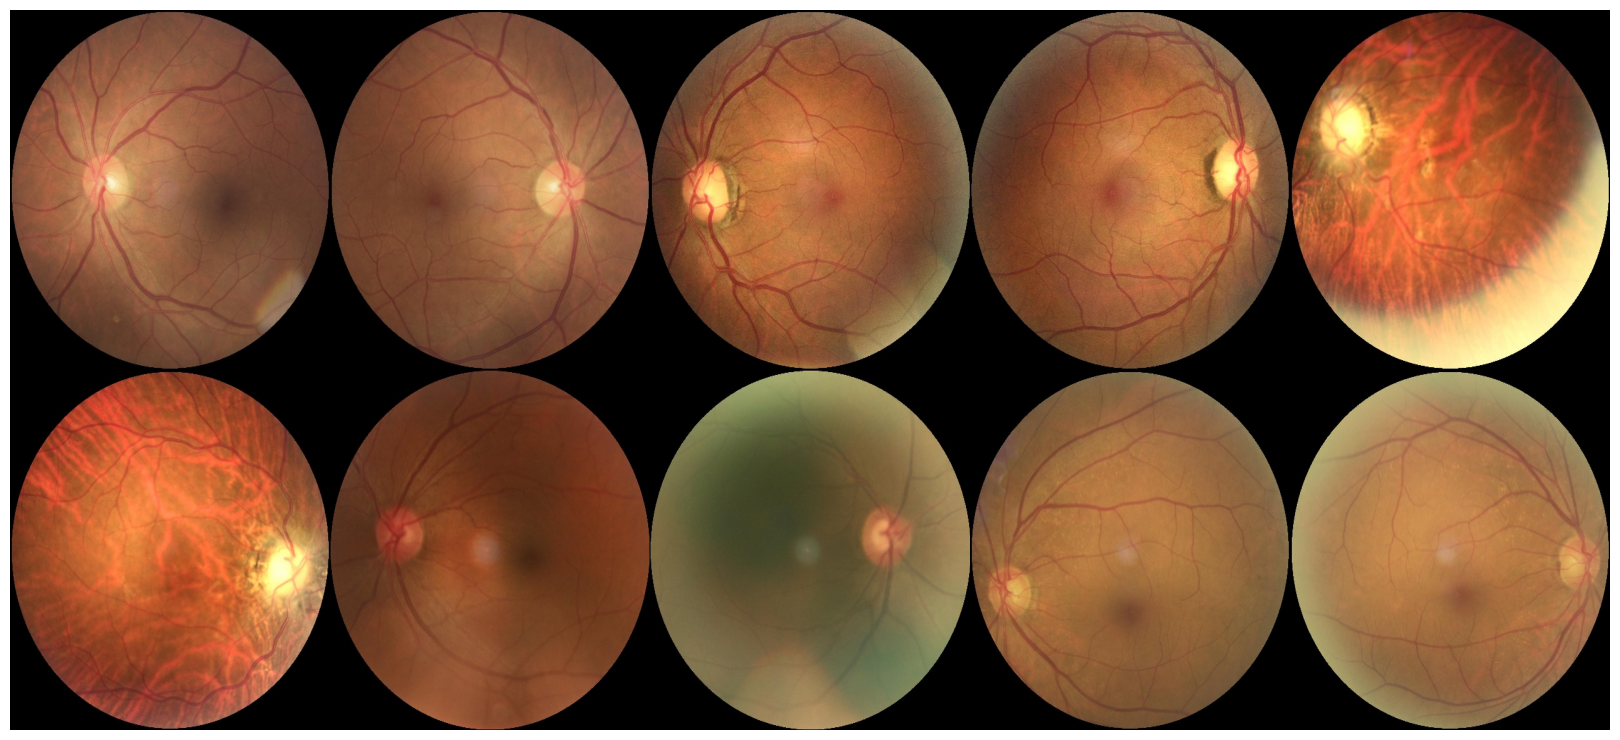

In [3]:
show_image_grid(
    image_dir="eye_disease_dataset/normal",
    n_cols=5,
    max_images=10,
    figsize=(16, 8)
)